### Key Intuition: Why Simple Duplication (Over-Sampling) Fails and Why SMOTE Exists

- **The Problem with `RandomOverSampler`:** It literally copies and pastes existing minority rows. If you duplicate a single point 20 times, the model builds a tiny, rigid boundary around that exact identical point, leading to heavy **overfitting**.
    
- **The Solution — SMOTE (Synthetic Minority Over-sampling Technique):** Instead of duplicating rows, SMOTE creates brand new, synthetic data points **along the line segment between a minority point and its $k$-nearest minority neighbors**.
    
- **The Variation — ADASYN (Adaptive Synthetic):** SMOTE generates equal points everywhere. ADASYN focuses generation specifically on minority samples that are harder to learn (those surrounded by majority class samples near decision boundaries).

# 3. Synthetic Sampling: SMOTE vs. ADASYN

This notebook covers:
1. **Why Synthetic Generation?**: Moving beyond simple duplication to avoid exact-match overfitting.
2. **SMOTE (Synthetic Minority Over-sampling Technique)**: Interpolating new points between $k$-nearest minority neighbors.
3. **ADASYN (Adaptive Synthetic)**: Adaptively focusing synthetic generation on hard-to-learn borderline samples.
4. **Visualizing the Synthetic Geometry**: Plotting 2D feature distributions before and after SMOTE/ADASYN.
5. **Evaluating Performance**: Benchmarking on a realistic, imbalanced test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE, ADASYN

# 1. Create a 2D imbalanced classification dataset (90:10 ratio) for easy 2D visualization
X_raw, y_raw = make_classification(
    n_samples=600,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.90, 0.10],
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X_raw, columns=['Feature_1', 'Feature_2'])
df['Target'] = y_raw

print("=== 1. RAW DATASET DISTRIBUTION ===")
display(df['Target'].value_counts().to_frame(name='Count').assign(
    Proportion=df['Target'].value_counts(normalize=True).map('{:.1%}'.format)
))

=== 1. RAW DATASET DISTRIBUTION ===


,Count,Proportion
Target,,
0,538,89.7%
1,62,10.3%


In [2]:
display(df)

,Feature_1,Feature_2,Target
0,-1.777396,0.094918,0
1,-1.405290,0.425859,0
2,-0.659961,1.387649,0
3,-0.670976,1.461806,0
4,-2.002950,-0.421017,0
...,...,...,...
595,-1.604730,1.578392,0
596,-0.608635,0.961252,0
597,-0.327800,1.051398,0
598,-0.912633,0.756672,0


---
## Step 1: Stratified Train / Test Split

As always, split before applying synthetic generation to prevent test leakage.

In [3]:
X = df.drop(columns=['Target']).copy()
y = df['Target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Original Train shape: {X_train.shape} | Majority: {(y_train == 0).sum()} | Minority: {(y_train == 1).sum()}")
print(f"Test shape: {X_test.shape}")

Original Train shape: (450, 2) | Majority: 403 | Minority: 47
Test shape: (150, 2)


---
## Step 2: Applying SMOTE & ADASYN

* **`SMOTE`**: Finds the $k=5$ nearest minority neighbors for each minority point and creates points along the lines between them.
* **`ADASYN`**: Adds a density distribution criterion to generate more points where minority samples are heavily outnumbered by neighboring majority points.

In [5]:
# 1. Apply smote to the training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2. Apply ADASYN to training data
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("=== RESAMPLED TRAINING SET SHAPES ===")
print(f"SMOTE:  {X_train_smote.shape} | Majority: {(y_train_smote == 0).sum()} | Synthetic Minority: {(y_train_smote == 1).sum()}")
print(f"ADASYN: {X_train_adasyn.shape} | Majority: {(y_train_adasyn == 0).sum()} | Synthetic Minority: {(y_train_adasyn == 1).sum()}")

=== RESAMPLED TRAINING SET SHAPES ===
SMOTE:  (806, 2) | Majority: 403 | Synthetic Minority: 403
ADASYN: (800, 2) | Majority: 403 | Synthetic Minority: 397


---
## Step 3: Visualizing the Geometric Differences

We plot the original training distribution versus the synthetic points generated by SMOTE and ADASYN.

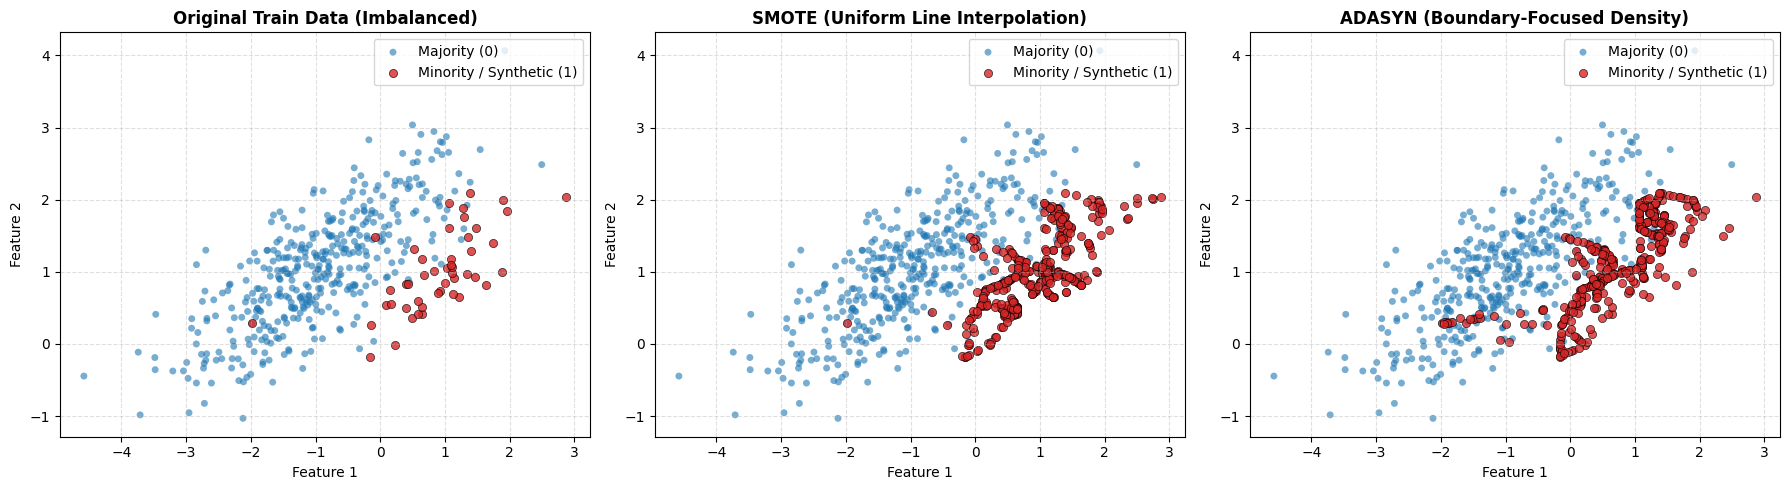

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ("Original Train Data (Imbalanced)", X_train.values, y_train.values),
    ("SMOTE (Uniform Line Interpolation)", X_train_smote.values, y_train_smote.values),
    ("ADASYN (Boundary-Focused Density)", X_train_adasyn.values, y_train_adasyn.values)
]

for ax, (title, X_plot, y_plot) in zip(axes, datasets):
    ax.scatter(X_plot[y_plot == 0, 0], X_plot[y_plot == 0, 1], label='Majority (0)', alpha=0.6, edgecolors='none', s=25, c='#1f77b4')
    ax.scatter(X_plot[y_plot == 1, 0], X_plot[y_plot == 1, 1], label='Minority / Synthetic (1)', alpha=0.8, edgecolors='black', linewidth=0.5, s=35, c='#d62728')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Step 4: Model Training and Evaluation

We train a Logistic Regression classifier on:
1. **Raw Imbalanced Data**
2. **SMOTE-resampled Data**
3. **ADASYN-resampled Data**

And evaluate all three models on the pristine, un-resampled test set.

In [8]:
# 1. baseline model
model_raw = LogisticRegression(random_state=42).fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)

# 2. smote model
model_smote = LogisticRegression(random_state=42).fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)

# 3. adasyn model
model_adasyn = LogisticRegression(random_state=42).fit(X_train_adasyn, y_train_adasyn)
y_pred_adasyn = model_adasyn.predict(X_test)

print("=== 1. BASELINE MODEL EVALUATION ===")
print(classification_report(y_test, y_pred_raw, target_names=['Majority (0)', 'Minority (1)'], zero_division=0))

print("=== 2. SMOTE MODEL EVALUATION ===")
print(classification_report(y_test, y_pred_smote, target_names=['Majority (0)', 'Minority (1)']))

print("=== 3. ADASYN MODEL EVALUATION ===")
print(classification_report(y_test, y_pred_adasyn, target_names=['Majority (0)', 'Minority (1)']))

=== 1. BASELINE MODEL EVALUATION ===
              precision    recall  f1-score   support

Majority (0)       0.98      0.99      0.99       135
Minority (1)       0.92      0.80      0.86        15

    accuracy                           0.97       150
   macro avg       0.95      0.90      0.92       150
weighted avg       0.97      0.97      0.97       150

=== 2. SMOTE MODEL EVALUATION ===
              precision    recall  f1-score   support

Majority (0)       0.99      0.92      0.95       135
Minority (1)       0.56      0.93      0.70        15

    accuracy                           0.92       150
   macro avg       0.78      0.93      0.83       150
weighted avg       0.95      0.92      0.93       150

=== 3. ADASYN MODEL EVALUATION ===
              precision    recall  f1-score   support

Majority (0)       0.99      0.87      0.92       135
Minority (1)       0.44      0.93      0.60        15

    accuracy                           0.87       150
   macro avg       0.7

---
## Comparison Summary

| Method | Generation Strategy | Strengths | Weaknesses |
| :--- | :--- | :--- | :--- |
| **`SMOTE`** | Generates points uniformly along line segments between nearest minority neighbors. | Creates realistic variety; avoids duplicate-row overfitting. | Can generate noisy points if minority points overlap heavily with majority points. |
| **`ADASYN`** | Adaptively generates more points near the decision boundary where classification is hard. | Focuses model capacity right on the difficult frontier. | Highly sensitive to noise/outliers (can over-synthesize around bad data). |

Here is the step-by-step mathematical breakdown for how **SMOTE** and **ADASYN** calculate tabular feature values, decide how many synthetic rows to generate, and how to choose the right strategy in practice.

---

### 1. Clarifying SMOTE Mechanics & Calculations

#### a) What is $\lambda$ and why is it random?

* $\lambda$ has **nothing to do with the target label ($y$)**. The target label for any newly generated synthetic point is **always $1$** (the minority class).
* $\lambda$ is a continuous decimal randomly chosen between $0.0$ and $1.0$ (for example, $\lambda = 0.42$).
* **Why it must be random:** If $\lambda$ was fixed at $0.5$, every synthetic point would sit exactly at the mathematical midpoint between two rows. By picking a random number like $0.23$ or $0.78$, SMOTE populates smooth, continuous points across the feature space, preventing rigid, artificial grid patterns.

---

#### b & c) Concrete Tabular Calculation: How Feature Columns Are Created

Let's look at real tabular numbers across two features (`Age`, `Income`) and the target column (`Fraud`):

Suppose we have two real minority fraud records:

* **Row $A$:** `Age = 25`, `Income = 40,000`, `Fraud = 1`
* **Row $B$ (Nearest Neighbor to $A$):** `Age = 35`, `Income = 60,000`, `Fraud = 1`

We pick a random $\lambda = 0.40$. The math applies to **every feature column individually**:

1. **Calculate the Feature Differences ($B - A$):**
* $\text{Diff}_{\text{Age}} = 35 - 25 = 10$
* $\text{Diff}_{\text{Income}} = 60,000 - 40,000 = 20,000$


2. **Multiply by $\lambda = 0.40$ and Add to Row $A$:**
* $\text{New Age} = 25 + (0.40 \times 10) = 25 + 4 = \mathbf{29}$
* $\text{New Income} = 40,000 + (0.40 \times 20,000) = 40,000 + 8,000 = \mathbf{48,000}$
* $\text{Target} = \mathbf{1}$



**The Resulting Table:**

| Row Type | Age | Income | Fraud (Target) |
| --- | --- | --- | --- |
| **Real Row $A$** | 25 | 40,000 | **1** |
| **Real Row $B$** | 35 | 60,000 | **1** |
| **Synthetic SMOTE Row** | **29** | **48,000** | **1** |

> **Note on Datasets with Only 1 Minority Row:** SMOTE requires at least $k+1$ minority samples (by default, $k=5$). If a dataset has only 1 minority row, SMOTE fails because it cannot calculate distances between neighbors; in that extreme edge case, random duplication or class weights must be used.

---

#### d) How Many Total Synthetic Rows Does SMOTE Create?

By default in `imbalanced-learn` (`sampling_strategy='auto'`):

* If you have **980 Class 0** rows and **20 Class 1** rows:
* **Target balance:** $1:1$ (equal to the majority class).
* **Total synthetic rows created:** $980 - 20 = \mathbf{960\text{ new rows}}$.
* **How they are distributed across the 20 points:**

$$\frac{960}{20} = 48\text{ synthetic rows per minority point}$$


* For each of the 20 minority points, SMOTE picks one of its $5$ nearest minority neighbors, draws a random $\lambda$, and generates a new synthetic row until all 960 rows are created.

---

### 2. How ADASYN Decides Where to Generate Points (Step-by-Step)

ADASYN also generates **960 total synthetic rows**, but instead of giving 48 rows to every point uniformly, it calculates a **difficulty ratio ($r_i$)**:

Suppose we examine two of the 20 minority fraud points ($k=5$ neighbors total):

* **Point 1 (Safe Zone):** Surrounded by 5 minority fraud cases and 0 legitimate cases $\rightarrow$ Difficulty ratio $r_1 = \frac{0}{5} = \mathbf{0.0}$.
* **Point 2 (Border Zone):** Surrounded by 4 legitimate cases and only 1 fraud case $\rightarrow$ Difficulty ratio $r_2 = \frac{4}{5} = \mathbf{0.8}$.

#### How ADASYN Allocates Rows:

1. It normalizes all $r_i$ ratios so they sum to $1$.
2. It multiplies the ratio by the total needed rows ($960$):
* **Point 1** gets $\mathbf{0}$ synthetic points generated around it (it is already easy to classify).
* **Point 2** gets $\approx \mathbf{80}$ synthetic points generated around it to help the model learn the difficult boundary.



---

### 3. Clear Decision Framework: Which Technique to Use in Real Projects

Here is the straightforward engineering decision hierarchy:

1. **Step 1: Always Try Cost-Sensitive Learning First (`class_weight='balanced'`)**
* *Why:* Modifies only the loss function; zero synthetic data risks, zero extra memory, zero training time overhead.
* *When to use:* Your first baseline for linear models, Random Forest, XGBoost (`scale_pos_weight`), and LightGBM.


2. **Step 2: Use SMOTE If Class Weights Yield Poor Recall**
* *When to use:* When you have continuous tabular features and want higher detection rates without severe overfitting.


3. **Step 3: Avoid ADASYN on Noisy / Outlier-Heavy Datasets**
* *Why:* Because ADASYN focuses heavily on points surrounded by the opposite class, a single noisy outlier or mislabeled data point will cause ADASYN to flood that error region with dozens of synthetic points.


4. **Step 4: Use Random Under-Sampling Only for Massive Big Data**
* *When to use:* Datasets with tens of millions of rows where training time is too slow and compute is constrained.



---